## Summary of the notebook

The notebook implements the end-to-end feature-engineering and data-transformation stage of the project, building on the datasets collected and integrated in previous assignments.

Specifically:


- Performs exploratory checks to validate data quality, including inspection of missing values, distributions, and correlations.
- Applies necessary data-cleaning steps such as datatype normalization, handling missing values, and removing redundant or highly correlated features.
- Engineers additional features that capture higher-level patterns, including:
    - A binary profitability target.
    - Industry-level profitability indicators.
    - Aggregated funding statistics.
    - External market-interest signals derived from Google Trends.

- Prepares the dataset for downstream analytical and machine-learning tasks by:
    - Encoding categorical variables.
    - Scaling numerical variables to ensure comparability.

- Saves intermediate and final transformed datasets for reproducibility and further modeling stages.

---

For the project a preprocessor was implemented.

### Summary of the Preprocessor

The GrowthPreprocessor class encapsulates the final, reusable preprocessing pipeline used to transform startup data into a format suitable for machine-learning models.

The preprocessor performs the following operations:

- Target handling 

Extracts and enforces a binary profitability target (Profitable ∈ {0,1}) for supervised learning.

- Categorical encoding. Applies one-hot encoding to nominal categorical variables such as:

    - Industry
    - Region
    - Exit status
    
This avoids imposing artificial ordinal relationships and ensures compatibility with common ML models.

- Numerical scaling

Scales all numeric features using RobustScaler, which is well-suited for financial data characterized by skewness and outliers (e.g., funding amounts, valuation, revenue).

- Schema preservation:

    - The list of numeric columns
    - The fitted scaling parameters
    - The final feature column order

This guarantees that the same transformations are applied consistently during training and inference, preventing data leakage and schema mismatch.

- Reproducibility and robustness

Separates the fit_transform step (used on training data) from the transform step (used on new or unseen data), ensuring a clean and reproducible preprocessing workflow.

---

1. Startup Failure Prediction Dataset
- Industry– Type of business (Tech, Healthcare, E-commerce, etc.)
- Startup Age – How many years the startup has been running
- Funding Amount – Total investment received
- Number of Founders – How many people started the company
- Founder Experience – Work experience of the founders
- Employees Count – Number of employees in the startup
- Revenue – How much money the startup makes
- Burn Rate – How much money the startup spends per month
- Market Size – Size of the industry (Small, Medium, Large)
- Business Model – Does the startup sell to businesses (B2B) or customers (B2C)?
- Product Uniqueness Score – How unique the startup’s product is (Scale: 1-10)
- Customer Retention Rate – Percentage of customers who return
- Marketing Expense – How much money is spent on marketing
- Startup Status – 1 = Successful, 0 = Failed (Did the startup succeed or fail?)

2. Startup Growth & Funding Trends
- Startup Name – The name of the startup (e.g., Startup_1, Startup_2).
- Industry – The sector in which the startup operates (e.g., AI, FinTech, HealthTech).
- Funding Rounds – The total number of funding rounds raised by the startup (1-5).
- Funding Amount (M USD) – The total amount of funding received in millions of USD.
- Valuation (M USD) – The startup’s post-money valuation in millions of USD.
- Revenue (M USD) – The estimated annual revenue in millions of USD.
- Employees – The number of employees working in the startup (ranging from 5 to 5000).
- Market Share (%) – The percentage of the market the startup has captured.
- Profitable – A binary indicator (1 = Profitable, 0 = Not Profitable).


## Exploratory data analysis

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
DATA_PATH_FAILURE = Path.cwd().parent.parent / "app" / "data" / "startup_failure_prediction.csv"
DATA_PATH_GROWTH =  Path.cwd().parent.parent / "app" / "data" / "startup_data_growth.csv"


In [44]:
data_failure = pd.read_csv(DATA_PATH_FAILURE)
data_growth = pd.read_csv(DATA_PATH_GROWTH)

### 1. Visualize outliers

#### a) boxplot

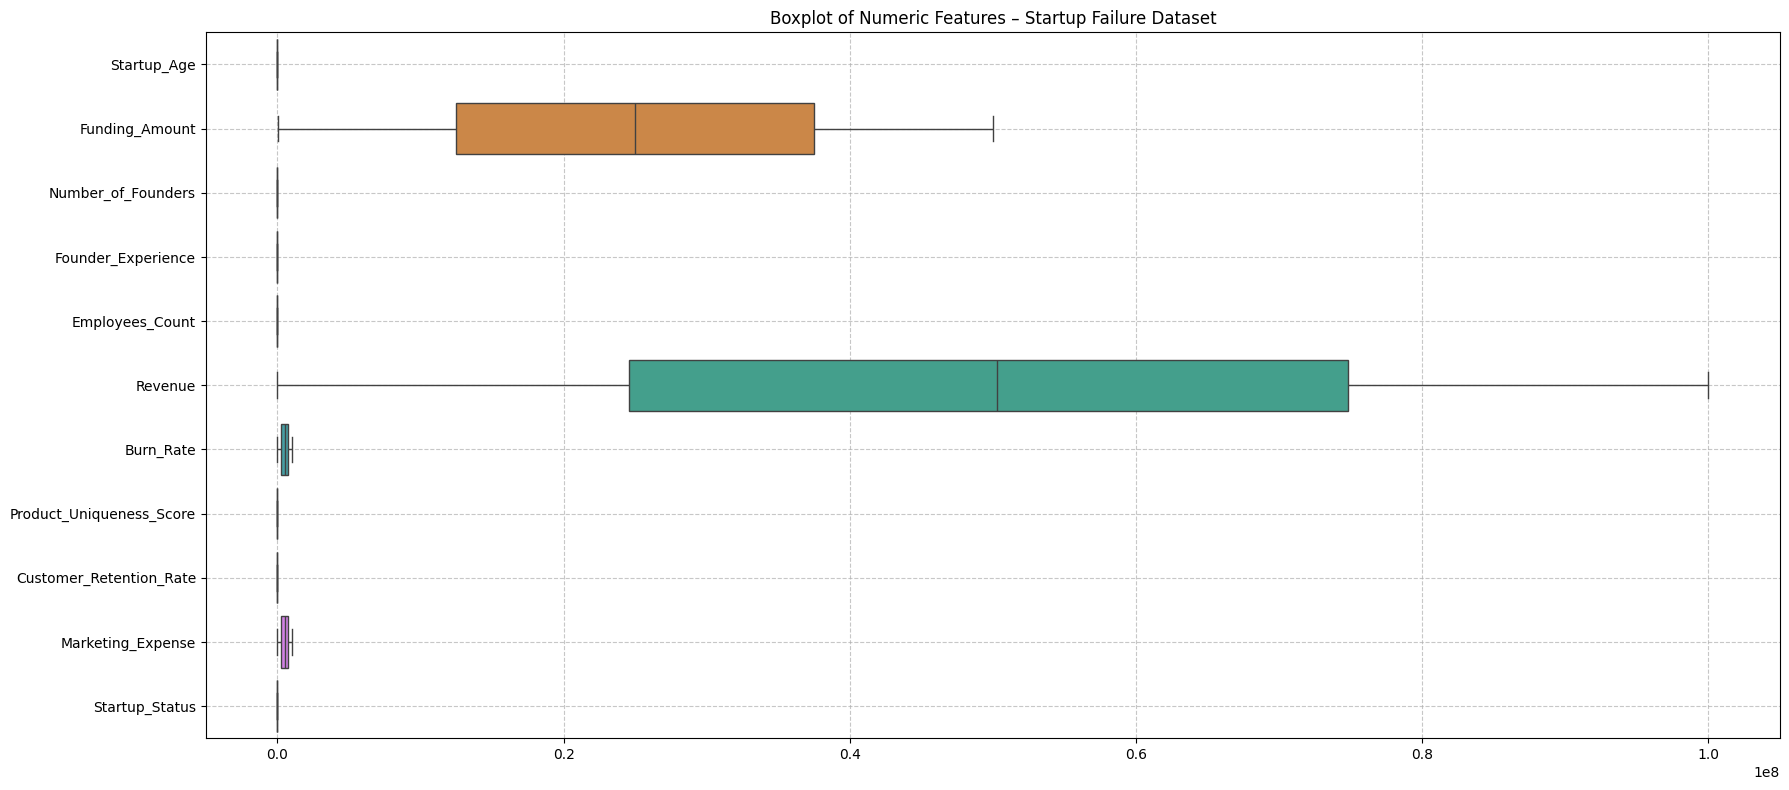

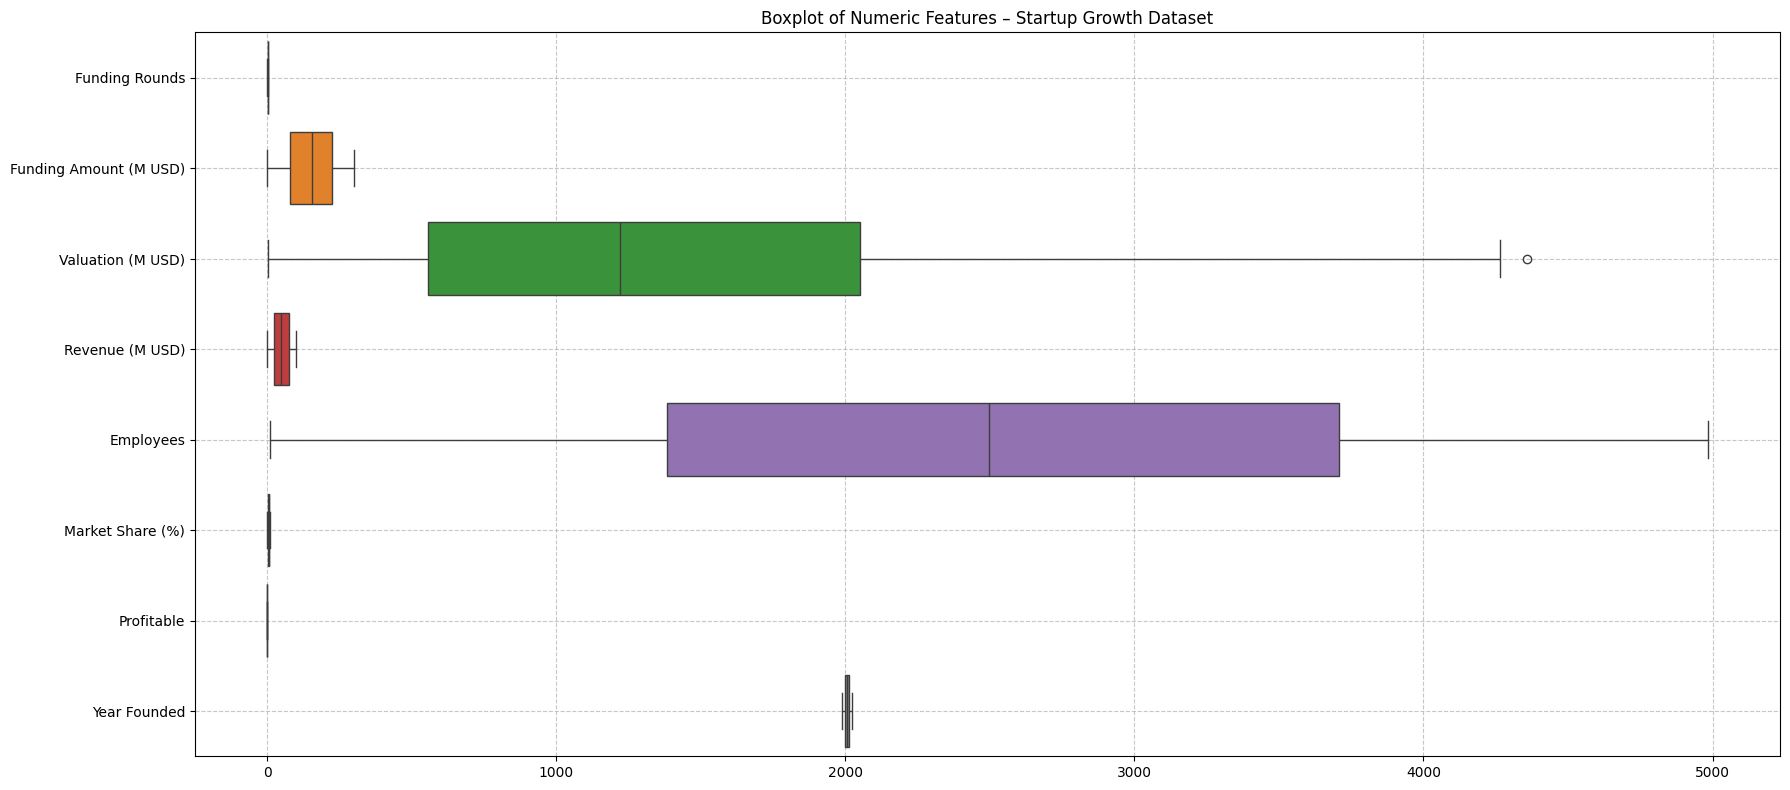

In [16]:
def plot_outliers(df, title):
    plt.figure(figsize=(18, 8))
    numeric_df = df.select_dtypes(include=['number'])

    sns.boxplot(data=numeric_df, orient='h')
    plt.title(f"Boxplot of Numeric Features – {title}")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot for both datasets
plot_outliers(data_failure, "Startup Failure Dataset")
plot_outliers(data_growth, "Startup Growth Dataset")

- Numeric features show strong right-skew, with many values clustered low and a few extremely high
- Features such as Valuation, Employees, and Revenue exhibit large spreads and extreme outliers

#### b) histogram

In [ ]:
target_failure = "Startup_Status"

# Identify categorical features
cat_failure = data_failure.select_dtypes(exclude=['number']).columns.tolist()

# Remove Startup_Name and target (if present)
for col in ["Startup_Name", target_failure]:
    if col in cat_failure:
        cat_failure.remove(col)

print("Categorical Columns (Failure Dataset):", cat_failure)

Categorical Columns (Failure Dataset): ['Industry', 'Market_Size', 'Business_Model']


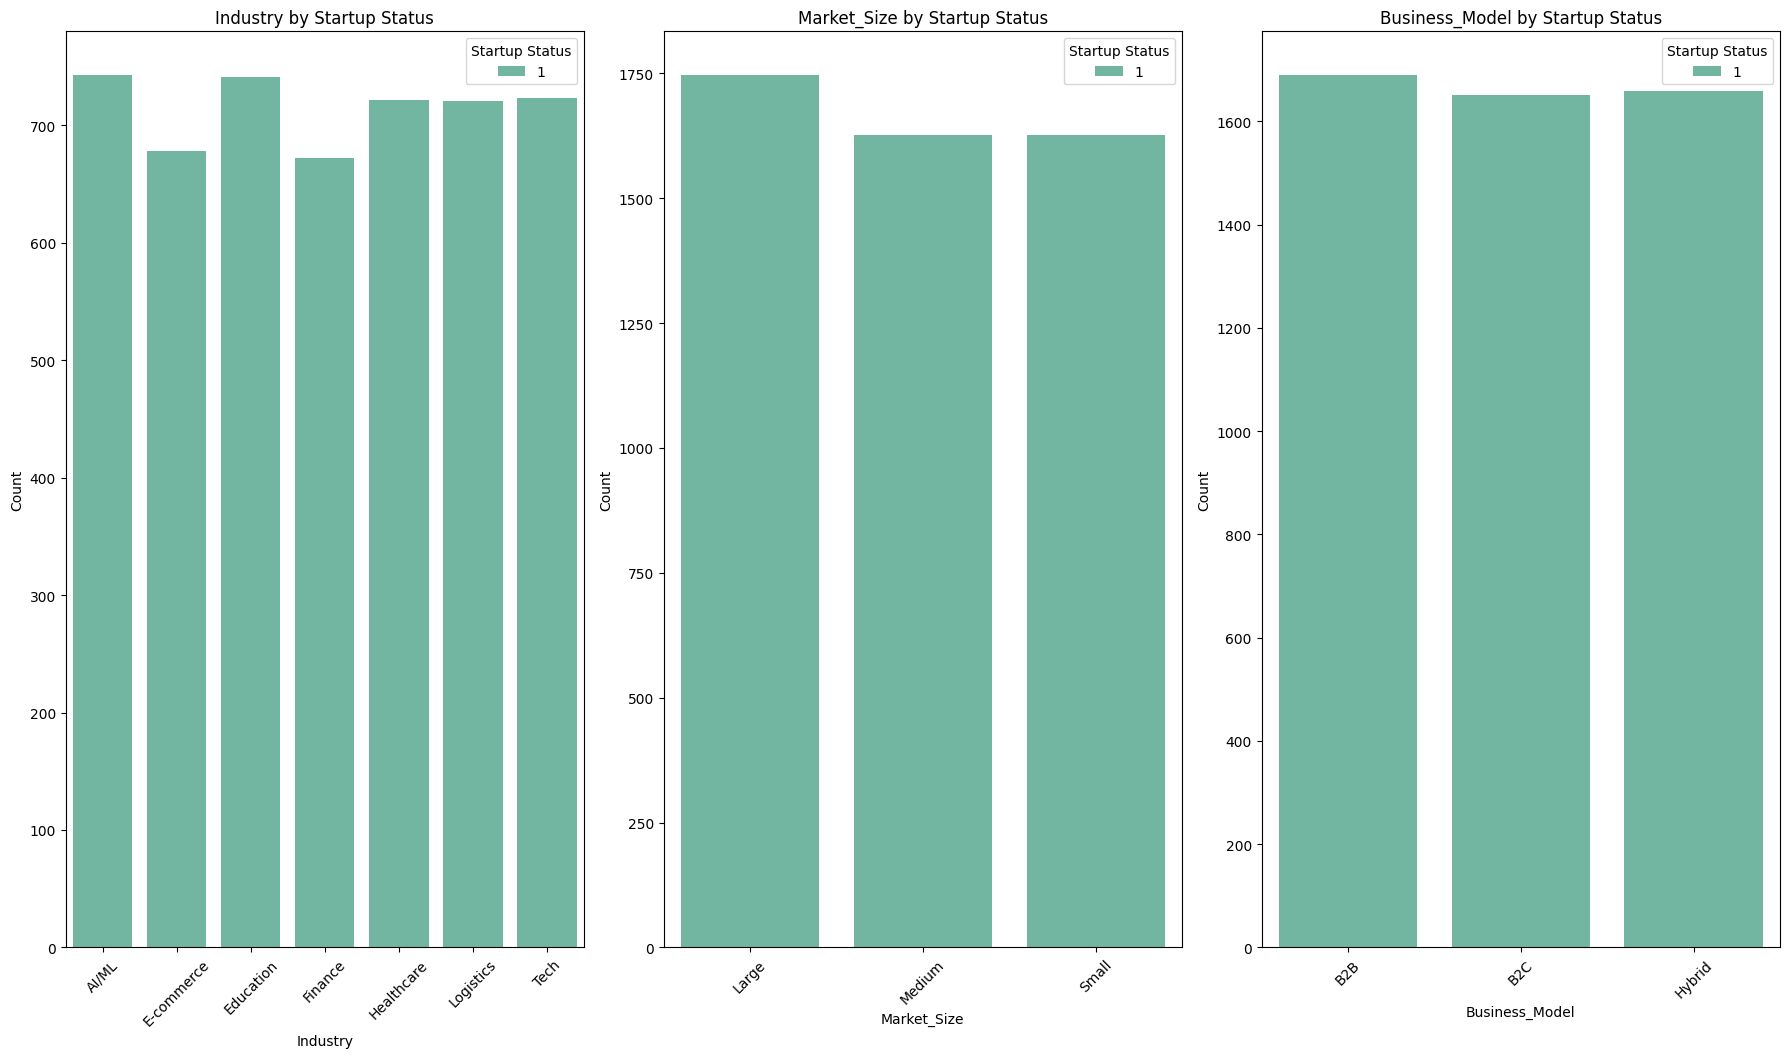

In [ ]:
plt.figure(figsize=(18, 20))

for i, col in enumerate(cat_failure, 1):
    plt.subplot(len(cat_failure)//3 + 1, 3, i)
    sns.countplot(
        data=data_failure,
        x=col,
        hue=target_failure,
        palette='Set2',
        order=sorted(data_failure[col].dropna().unique())
    )
    plt.title(f"{col} by Startup Status")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Startup Status")

plt.tight_layout()
plt.show()

- The categorical variables in the Startup Failure dataset are well-balanced, with no major class imbalance issues

In [33]:
# Identify categorical features
cat_growth = data_growth.select_dtypes(exclude=['number']).columns.tolist()

# Remove Startup_Name
if "Startup Name" in cat_growth:
    cat_growth.remove("Startup Name")

print("Categorical Columns (Growth Dataset):", cat_growth)


Categorical Columns (Growth Dataset): ['Industry', 'Region', 'Exit Status']


C:\Users\mraic\AppData\Local\Temp\ipykernel_9048\1752532850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\mraic\AppData\Local\Temp\ipykernel_9048\1752532850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\mraic\AppData\Local\Temp\ipykernel_9048\1752532850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


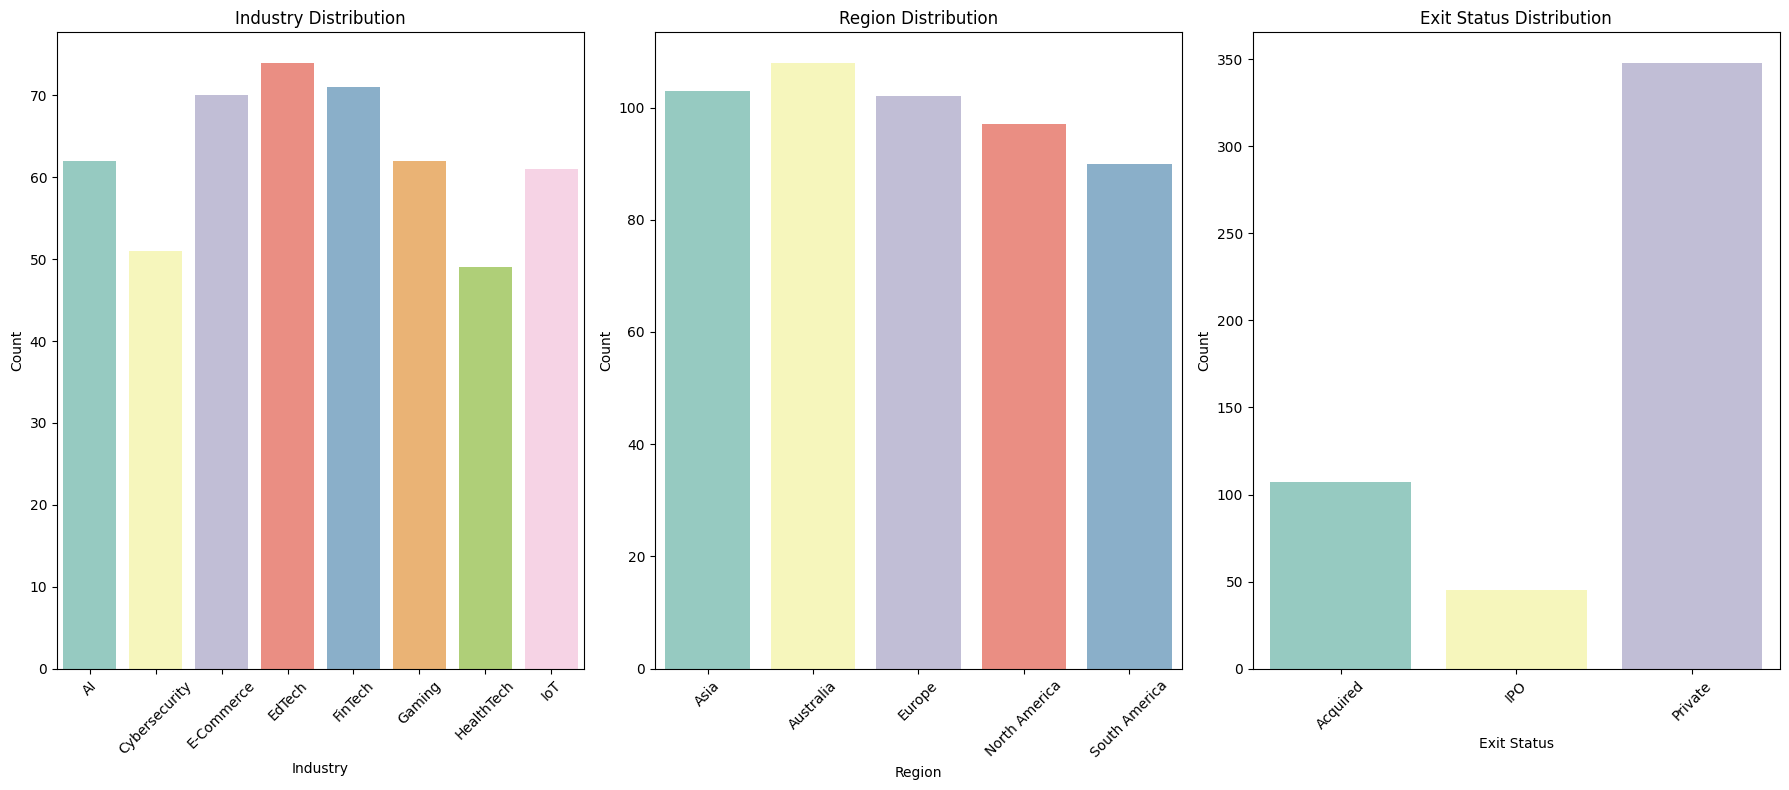

In [34]:
plt.figure(figsize=(18, 8))

for i, col in enumerate(cat_growth, 1):
    plt.subplot(1, len(cat_growth), i)
    sns.countplot(
        data=data_growth,
        x=col,
        palette='Set3',
        order=sorted(data_growth[col].dropna().unique())
    )
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


- The categorical features for the second dataset is well balanced except "Exit status" , “Private” startups represent the majority, while “Acquired” and especially “IPO” appear much less frequently

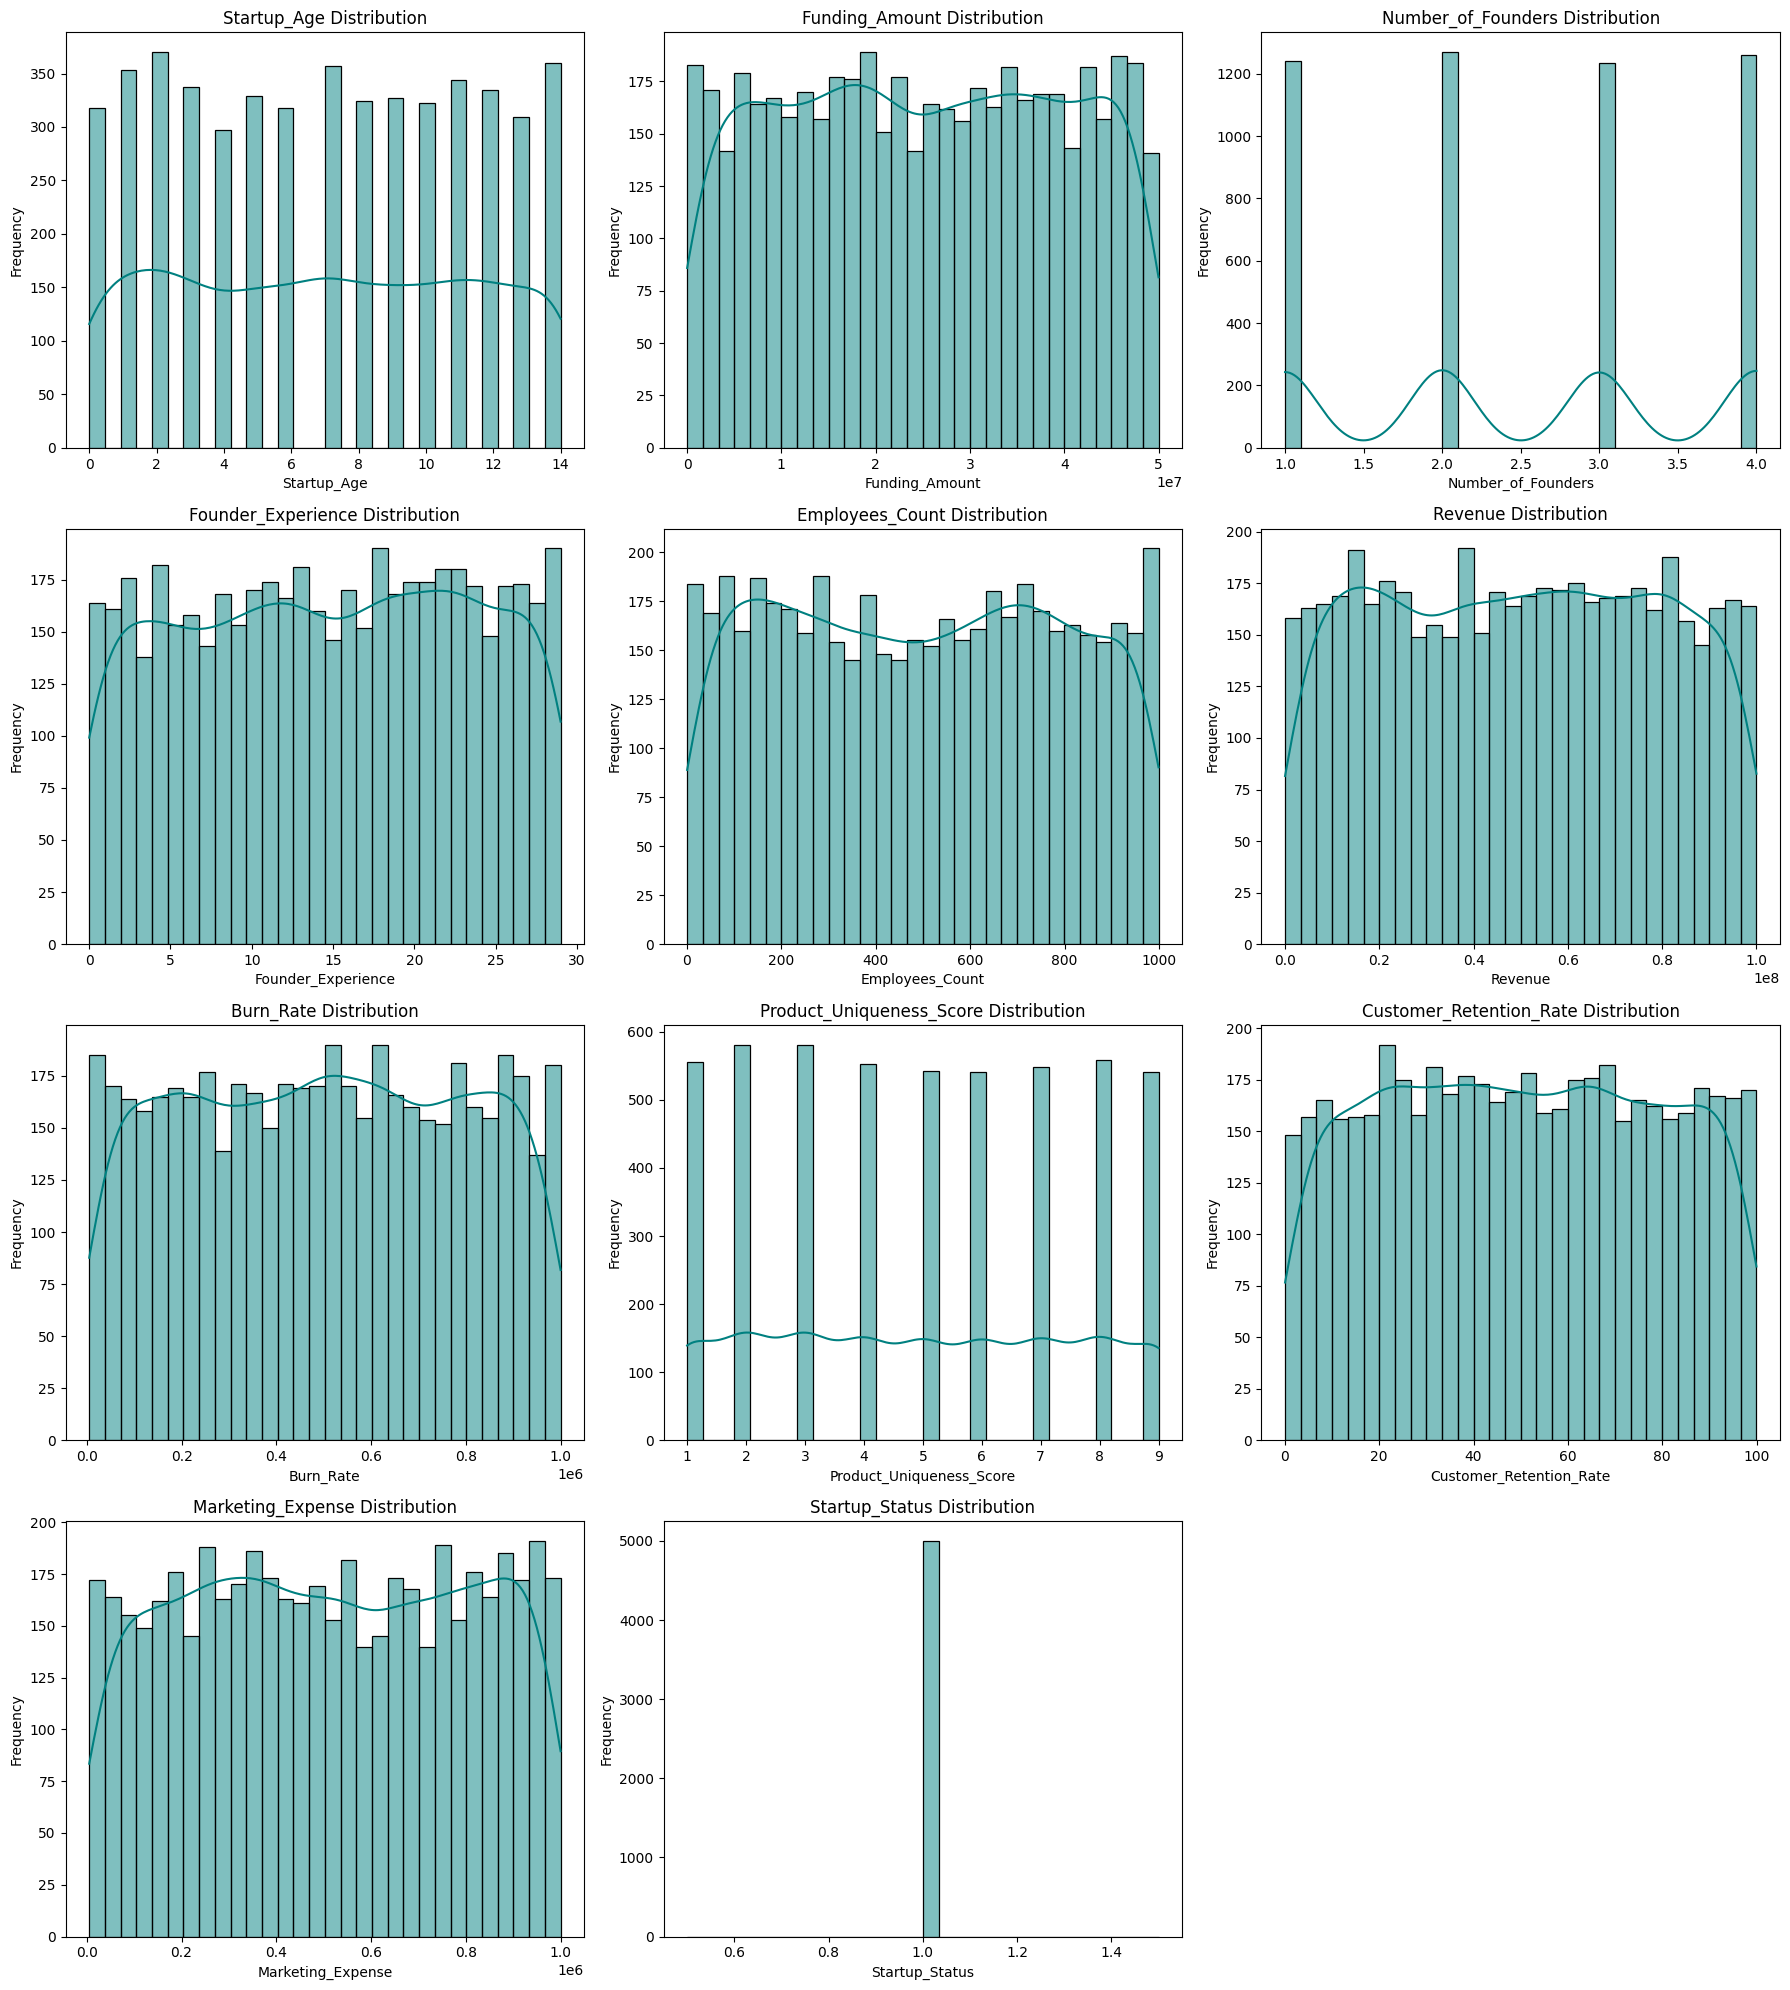

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_failure = data_failure.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(18, 20))

for i, col in enumerate(num_failure, 1):
    plt.subplot(len(num_failure)//3 + 1, 3, i)
    sns.histplot(data_failure[col], kde=True, bins=30, color='teal')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


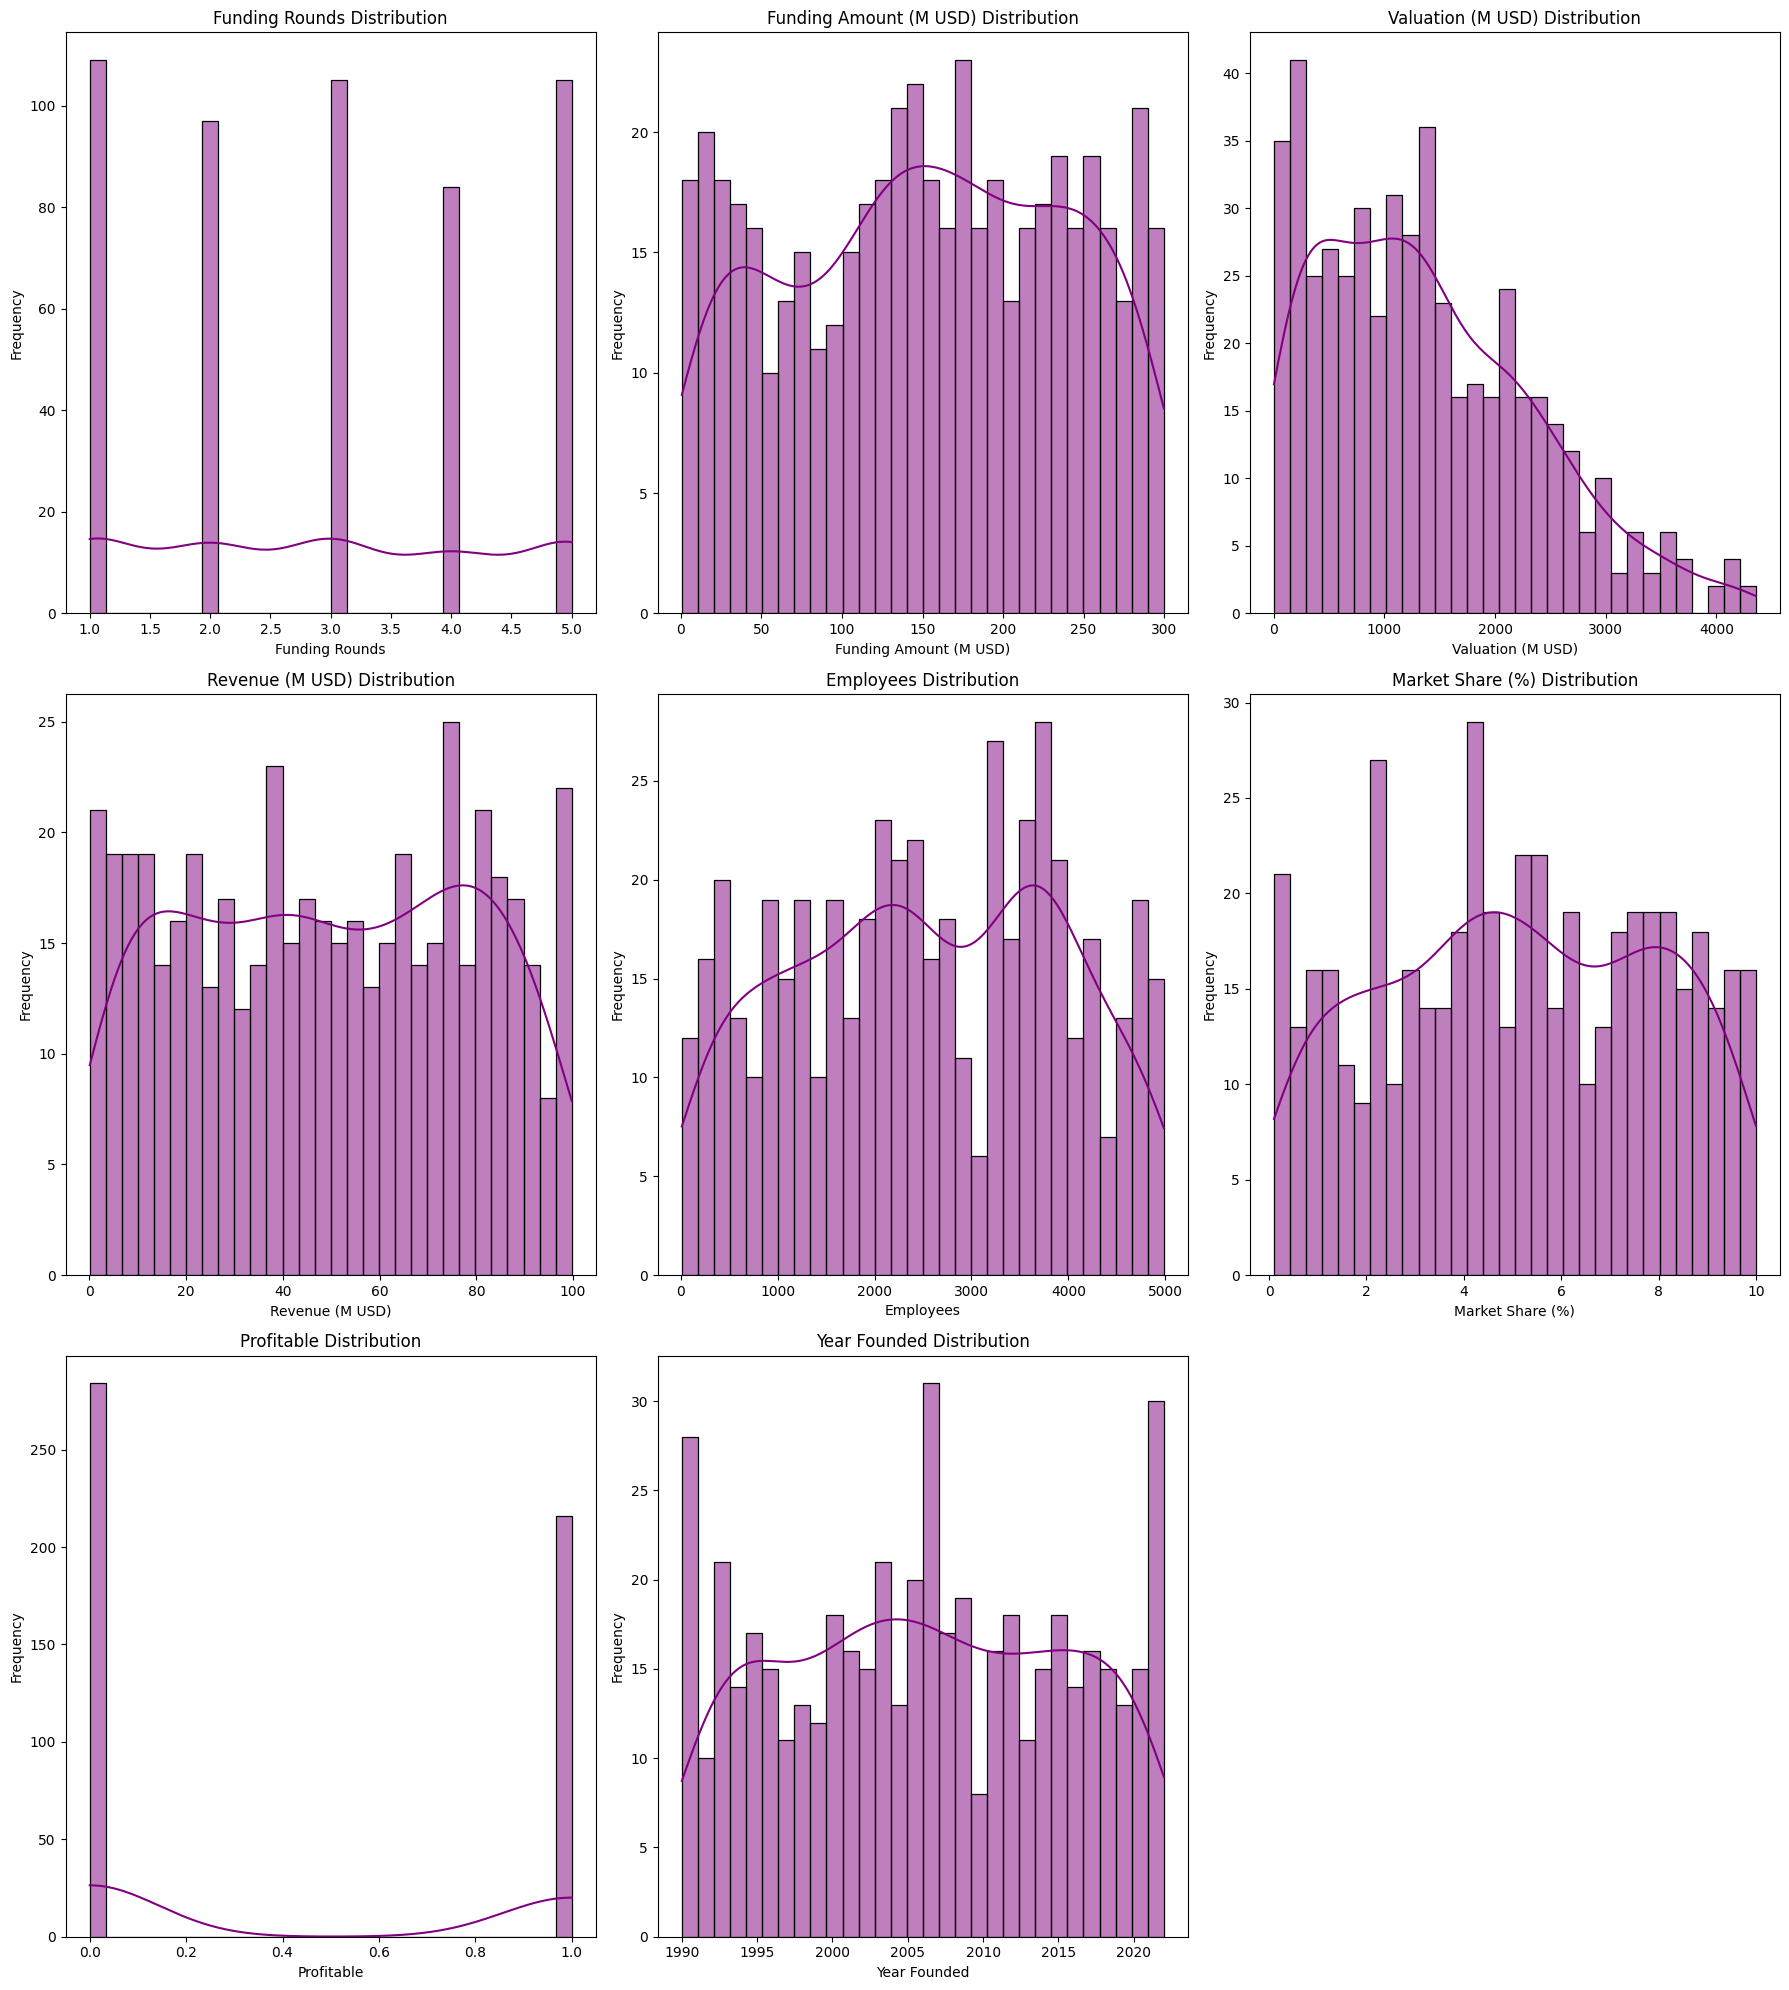

In [64]:
# Select numerical columns
num_growth = data_growth.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(18, 20))

for i, col in enumerate(num_growth, 1):
    plt.subplot(len(num_growth)//3 + 1, 3, i)
    sns.histplot(data_growth[col], kde=True, bins=30, color='purple')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### 2. Search for nan values

In [35]:
data_failure.isna().sum()

Startup_Name                0
Industry                    0
Startup_Age                 0
Funding_Amount              0
Number_of_Founders          0
Founder_Experience          0
Employees_Count             0
Revenue                     0
Burn_Rate                   0
Market_Size                 0
Business_Model              0
Product_Uniqueness_Score    0
Customer_Retention_Rate     0
Marketing_Expense           0
Startup_Status              0
dtype: int64

In [36]:
data_growth.isna().sum()

Startup Name              0
Industry                  0
Funding Rounds            0
Funding Amount (M USD)    0
Valuation (M USD)         0
Revenue (M USD)           0
Employees                 0
Market Share (%)          0
Profitable                0
Year Founded              0
Region                    0
Exit Status               0
dtype: int64

- There are no missing values

## Data Cleaning & Analysis


### 1. Visualize key relationships

#### Correlation matrix

In [57]:
data_failure.dtypes

Startup_Name                 object
Industry                     object
Startup_Age                   int64
Funding_Amount                int64
Number_of_Founders            int64
Founder_Experience            int64
Employees_Count               int64
Revenue                       int64
Burn_Rate                     int64
Market_Size                  object
Business_Model               object
Product_Uniqueness_Score      int64
Customer_Retention_Rate     float64
Marketing_Expense             int64
Startup_Status                int64
dtype: object

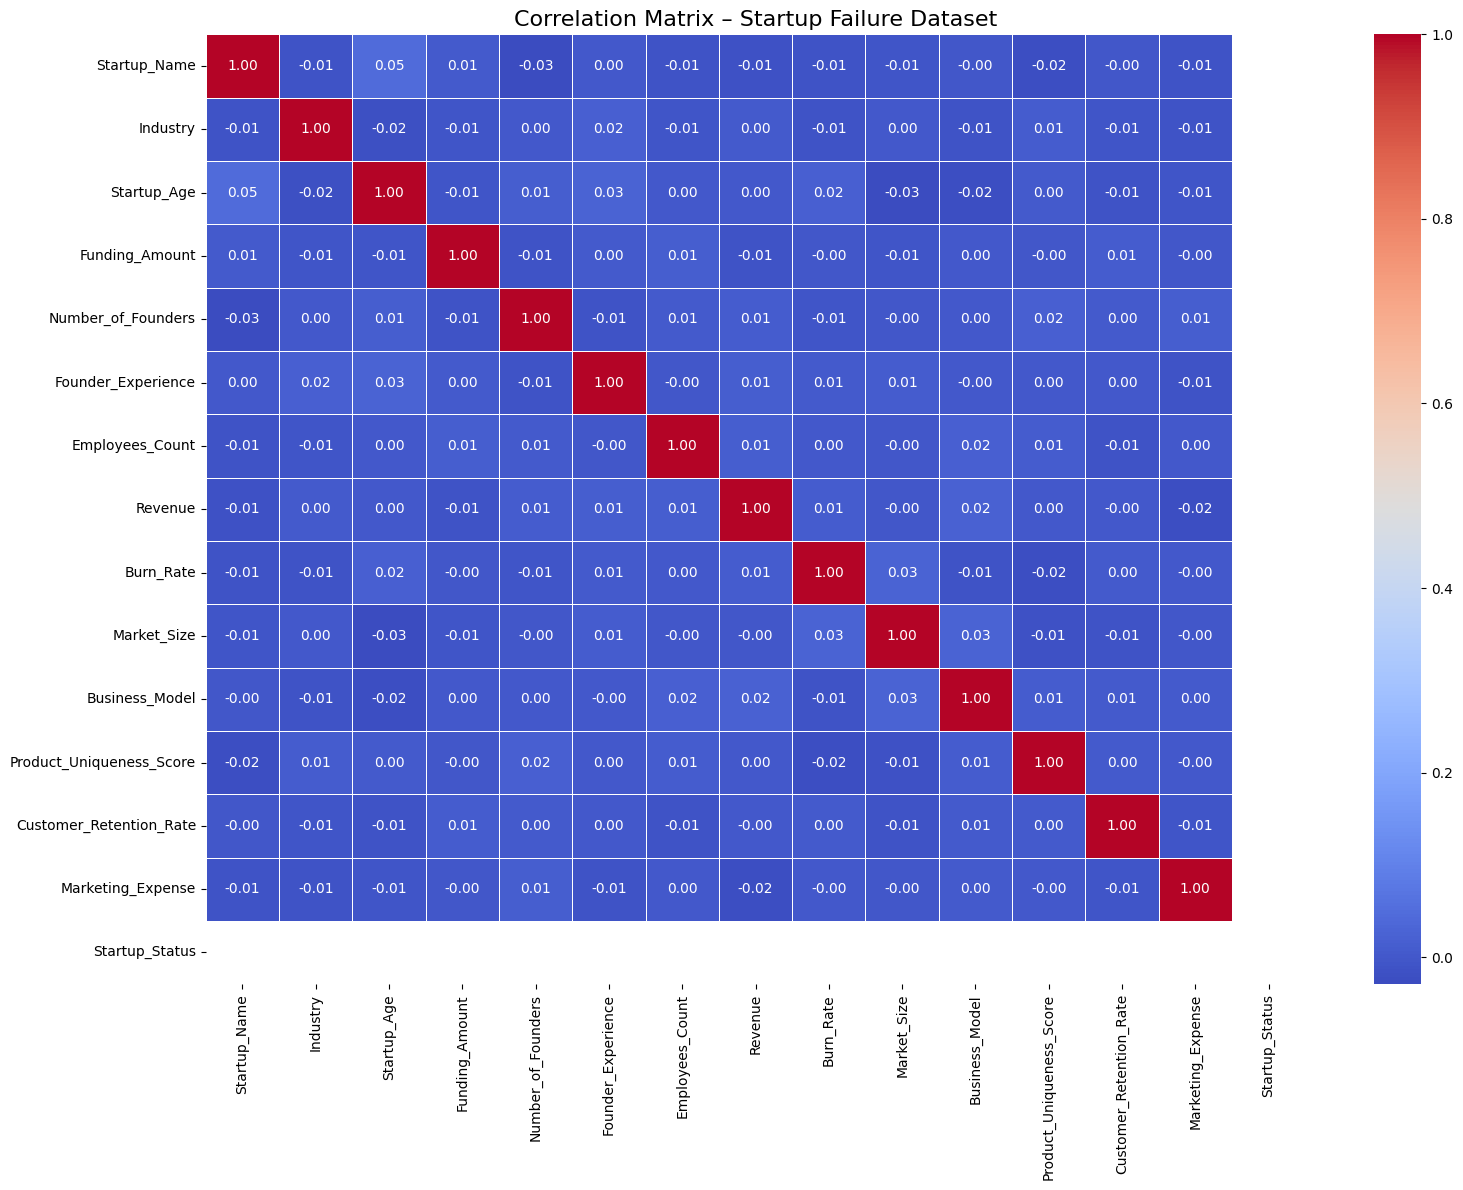

In [60]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Copy dataset
failure_encoded = data_failure.copy()

# Encode categorical features
le = LabelEncoder()
for col in failure_encoded.select_dtypes(include=['object']).columns:
    failure_encoded[col] = le.fit_transform(failure_encoded[col].astype(str))

# Compute correlation
corr_failure = failure_encoded.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_failure, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Correlation Matrix – Startup Failure Dataset", fontsize=16)
plt.tight_layout()
plt.show()


- the correlation is neutral between the features
- Startup_Status has no variance (all values are the same) = 1, this is why it shows up blank.

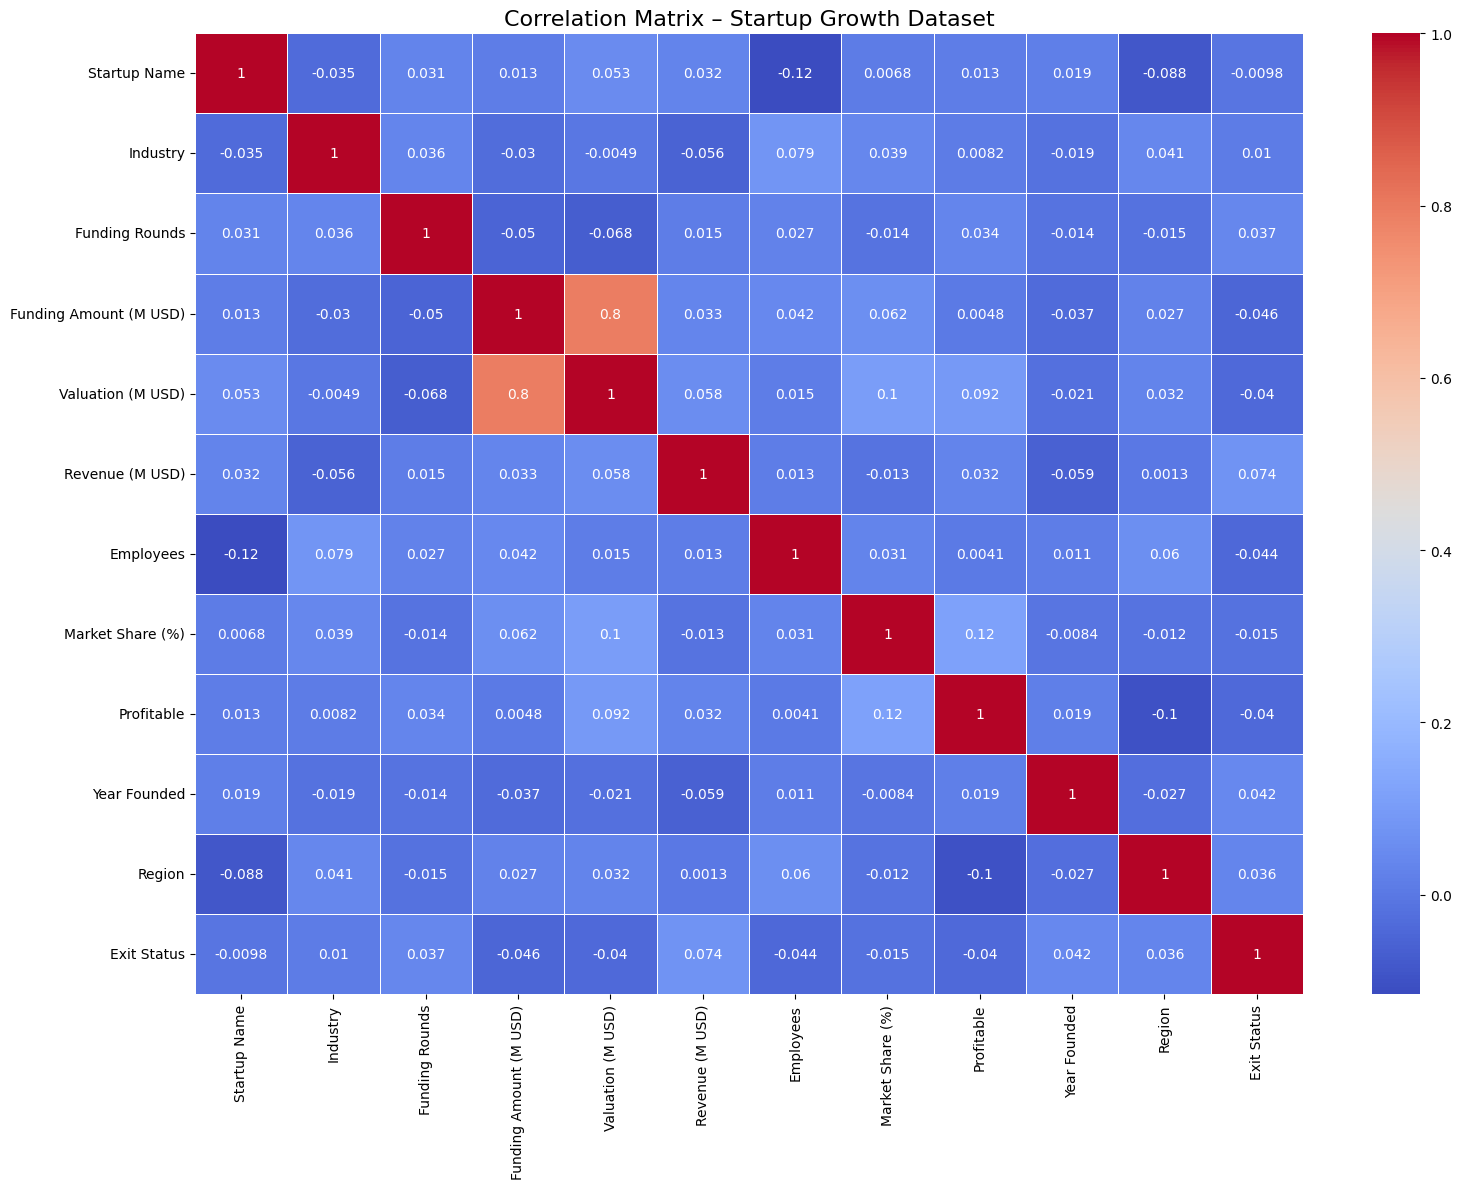

In [61]:
# Copy dataset
growth_encoded = data_growth.copy()

# Encode categorical features
le = LabelEncoder()
for col in growth_encoded.select_dtypes(include=['object']).columns:
    growth_encoded[col] = le.fit_transform(growth_encoded[col].astype(str))

# Compute correlation
corr_growth = growth_encoded.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_growth, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix – Startup Growth Dataset", fontsize=16)
plt.tight_layout()
plt.show()


- The correlation is neutral excepting Valuation and Funding Amount

### 2. Handle missing or inconsistent values
- The feature Funding Amount (M USD) is highly correlated with Valuation (M USD).
- This means both features carry almost the same information, creating multicollinearity, which can:
    - distort model coefficients
    - reduce model interpretability
    - weaken generalization

In [ ]:
data_growth_cleaned = data_growth.drop(columns=["Funding Amount (M USD)"])
data_growth_cleaned.head()

,Startup Name,Industry,Funding Rounds,Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Region,Exit Status
0,Startup_1,IoT,1,844.75,67.87,1468,5.20,0,2006,Europe,Private
1,Startup_2,EdTech,1,3310.83,75.65,3280,8.10,1,2003,South America,Private
2,Startup_3,EdTech,1,1059.37,84.21,4933,2.61,1,1995,South America,Private
3,Startup_4,Gaming,5,101.90,47.08,1059,2.53,0,2003,South America,Private
4,Startup_5,IoT,4,850.11,50.25,1905,4.09,0,1997,Europe,Acquired


## Feature Engineering
### 1. Create useful features from existing ones: The Startup status has only one value = 1 so we need also negative values, thus the target feature will be Profitable and it will be extracted.

In [ ]:
# Copy dataset to avoid overwriting original
data_failure_fe = data_failure.copy()

# Create annual expense
data_failure_fe["Annual_Expense"] = (data_failure_fe["Burn_Rate"] * 12) + data_failure_fe["Marketing_Expense"]

# Create profit feature
data_failure_fe["Profit"] = data_failure_fe["Revenue"] - data_failure_fe["Annual_Expense"]

# Create profitability label
data_failure_fe["Is_Profitable"] = data_failure_fe["Profit"].apply(
    lambda x: "Yes" if x > 0 else "No"
)

data_failure_fe.head()

,Startup_Name,Industry,Startup_Age,Funding_Amount,Number_of_Founders,Founder_Experience,Employees_Count,Revenue,Burn_Rate,Market_Size,Business_Model,Product_Uniqueness_Score,Customer_Retention_Rate,Marketing_Expense,Startup_Status,Annual_Expense,Profit,Is_Profitable
0,Startup_1,Logistics,8,18328419,2,13,581,97866143,602731,Medium,B2B,2,79.61,987830,1,8220602,89645541,Yes
1,Startup_2,Education,3,39753708,3,16,529,36868744,820698,Large,B2C,3,32.47,599615,1,10447991,26420753,Yes
2,Startup_3,Healthcare,14,18073294,1,28,82,3478737,992205,Small,B2C,1,9.88,780730,1,12687190,-9208453,No
3,Startup_4,E-commerce,5,19435653,4,14,234,80716899,536747,Medium,B2C,9,23.20,188588,1,6629552,74087347,Yes
4,Startup_5,Finance,14,4205797,4,17,960,53347246,555199,Medium,Hybrid,3,73.52,310892,1,6973280,46373966,Yes


### 2. Proper encoding

In [80]:
# For Market Size
# Ordinal mapping
market_size_map = {
    "Small": 0,
    "Medium": 1,
    "Large": 2
}

# For profitable
# Apply mapping
data_failure_fe["Market_Size_Ordinal"] = data_failure_fe["Market_Size"].map(market_size_map)


data_failure_fe["Is_Profitable_Binary"] = data_failure_fe["Is_Profitable"].map({
    "Yes": 1,
    "No": 0
})

data_failure_fe = data_failure_fe.drop(columns=["Is_Profitable", "Market_Size"])


# One-hot encode selected categorical features
failure_ohe = pd.get_dummies(
    data_failure_fe,
    columns=["Industry", "Business_Model"],
    drop_first=True  # avoids multicollinearity
)

failure_ohe.head()


,Startup_Name,Startup_Age,Funding_Amount,Number_of_Founders,Founder_Experience,Employees_Count,Revenue,Burn_Rate,Product_Uniqueness_Score,Customer_Retention_Rate,...,Market_Size_Ordinal,Is_Profitable_Binary,Industry_E-commerce,Industry_Education,Industry_Finance,Industry_Healthcare,Industry_Logistics,Industry_Tech,Business_Model_B2C,Business_Model_Hybrid
0,Startup_1,8,18328419,2,13,581,97866143,602731,2,79.61,...,1,1,False,False,False,False,True,False,False,False
1,Startup_2,3,39753708,3,16,529,36868744,820698,3,32.47,...,2,1,False,True,False,False,False,False,True,False
2,Startup_3,14,18073294,1,28,82,3478737,992205,1,9.88,...,0,0,False,False,False,True,False,False,True,False
3,Startup_4,5,19435653,4,14,234,80716899,536747,9,23.20,...,1,1,True,False,False,False,False,False,True,False
4,Startup_5,14,4205797,4,17,960,53347246,555199,3,73.52,...,1,1,False,False,True,False,False,False,False,True


In [86]:
# One-hot encode Industry in the growth dataset
growth_ohe = pd.get_dummies(
    data_growth,
    columns=["Industry", "Region", "Exit Status"],
    drop_first=True
)

growth_ohe.head()


,Startup Name,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Industry_Cybersecurity,...,Industry_FinTech,Industry_Gaming,Industry_HealthTech,Industry_IoT,Region_Australia,Region_Europe,Region_North America,Region_South America,Exit Status_IPO,Exit Status_Private
0,Startup_1,1,101.09,844.75,67.87,1468,5.20,0,2006,False,...,False,False,False,True,False,True,False,False,False,True
1,Startup_2,1,247.62,3310.83,75.65,3280,8.10,1,2003,False,...,False,False,False,False,False,False,False,True,False,True
2,Startup_3,1,109.24,1059.37,84.21,4933,2.61,1,1995,False,...,False,False,False,False,False,False,False,True,False,True
3,Startup_4,5,10.75,101.90,47.08,1059,2.53,0,2003,False,...,False,True,False,False,False,False,False,True,False,True
4,Startup_5,4,249.28,850.11,50.25,1905,4.09,0,1997,False,...,False,False,False,True,False,True,False,False,False,False


- Perform normalization/standardization


In [81]:
from sklearn.preprocessing import RobustScaler

failure_numeric_cols = [
    col for col in failure_ohe.columns
    if failure_ohe[col].dtype != "uint8"    # excludes dummy vars
    and col not in ["Is_Profitable_Binary"] 
    and col not in ["Market_Size_Ordinal"] 
    and col not in ["Startup_Name"] 
]

scaler_failure = RobustScaler()

failure_ohe_scaled = failure_ohe.copy()
failure_ohe_scaled[failure_numeric_cols] = scaler_failure.fit_transform(
    failure_ohe_scaled[failure_numeric_cols]
)


In [88]:
growth_numeric_cols = [
    col for col in growth_ohe.columns
    if growth_ohe[col].dtype != "uint8"
    and col not in ["Profitable"]   # target
    and col not in ["Startup Name"] 
]

scaler_growth = RobustScaler()

growth_ohe_scaled = growth_ohe.copy()
growth_ohe_scaled[growth_numeric_cols] = scaler_growth.fit_transform(
    growth_ohe_scaled[growth_numeric_cols]
)


In [ ]:
output_path = Path.cwd().parent.parent / "app" / "data"
failure_ohe_scaled.to_csv(output_path / "startup_failure_processed.csv", index=False)
growth_ohe_scaled.to_csv(output_path / "startup_growth_processed.csv", index=False)

In [9]:
import pandas as pd
from pathlib import Path


output_path = Path.cwd().parent.parent / "app" / "data"
d = pd.read_csv(output_path / "startup_failure_prediction.csv")

In [8]:
list(set(d.Industry))

['Gaming',
 'Cybersecurity',
 'E-Commerce',
 'AI',
 'EdTech',
 'HealthTech',
 'FinTech',
 'IoT']

In [10]:
list(set(d.Industry))

['Finance',
 'Logistics',
 'Education',
 'Healthcare',
 'AI/ML',
 'Tech',
 'E-commerce']